# IncidentLens — Stage 5: Exploratory Data Analysis

Every chart in this notebook is here to answer a specific question about the primary dataset (100,000 IT support tickets). No decorative charts.

This notebook loads the **cleaned** dataset (`src.preprocessing.clean_tickets`), not the raw CSV, so results reflect Stage 4's transformations (e.g. `region` filled with `"unknown"`, `has_resolution` flag added).

In [11]:
import sys
sys.path.append('..')  # so `import src...` works from notebooks/

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_primary_dataset
from src.preprocessing import clean_tickets

sns.set_theme(style='whitegrid')

raw = load_primary_dataset()
df = clean_tickets(raw)
print(f'{len(df)} rows, {len(df.columns)} columns')
df.head(3)

100000 rows, 22 columns


,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region,has_valid_message,has_resolution
0,TCKT_000001,2024-01-31 05:14:27+00:00,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,eu,True,True
1,TCKT_000002,2024-10-20 06:15:49+00:00,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,unknown,True,True
2,TCKT_000003,2024-06-18 21:35:54+00:00,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,...,<NA>,NaN,0,neutral,3,0,android,mea,True,False


## 1. Missingness

**Question:** which fields actually have missing data, and how much?

This confirms Stage 2/4's findings visually and is the reference point for every analysis below that has to account for missing values.

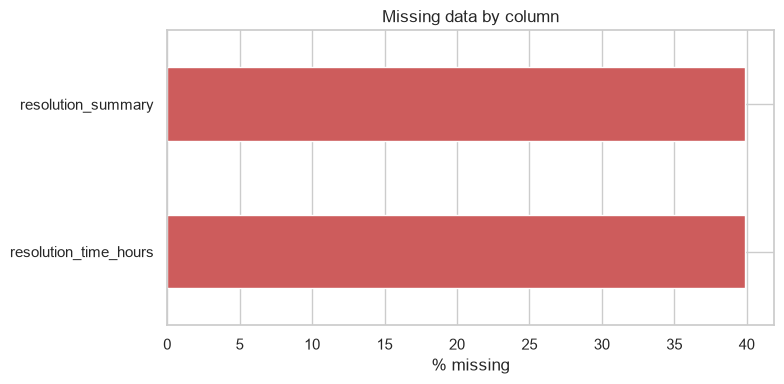

resolution_time_hours    39.887
resolution_summary       39.887
dtype: float64

In [12]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel('% missing')
ax.set_title('Missing data by column')
plt.tight_layout()
plt.show()

missing_pct

## 2. Incident categories (`issue_type`)

**Question:** what kinds of incidents make up this dataset, and how balanced are the categories? This matters directly for Stage 15 — `issue_type` is the leading candidate classification target, and severe imbalance would need to be addressed before training.

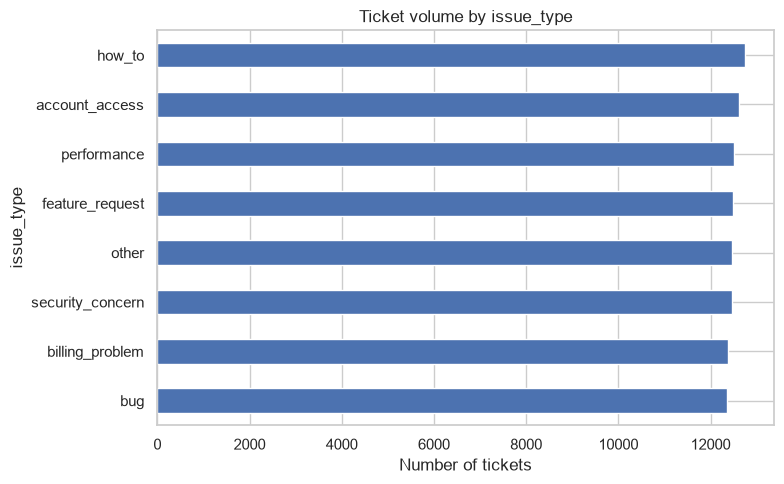

Class balance (%):
issue_type
how_to              12.74
account_access      12.61
performance         12.51
feature_request     12.49
other               12.46
security_concern    12.46
billing_problem     12.38
bug                 12.35
Name: count, dtype: double[pyarrow]


In [13]:
issue_counts = df['issue_type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
issue_counts.plot(kind='barh', ax=ax)
ax.set_xlabel('Number of tickets')
ax.set_title('Ticket volume by issue_type')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Class balance (%):')
print((issue_counts / len(df) * 100).round(2))

## 3. Severity (`priority`)

**Question:** how are tickets distributed across priority levels? A dataset with almost no high-priority tickets would limit what trend/pattern analysis can say.

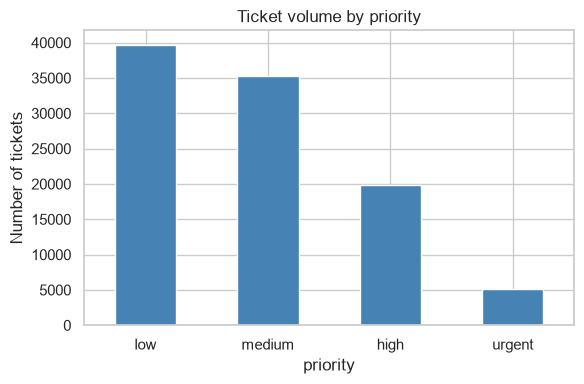

priority
low       39735
medium    35313
high      19865
urgent     5087
Name: count, dtype: int64[pyarrow]

In [14]:
priority_counts = df['priority'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
priority_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Number of tickets')
ax.set_title('Ticket volume by priority')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

priority_counts

## 4. Ticket frequency over time

**Question:** is ticket volume stable, growing, or seasonal across the dataset's timeframe? This sets expectations for Stage 12's trend analysis.

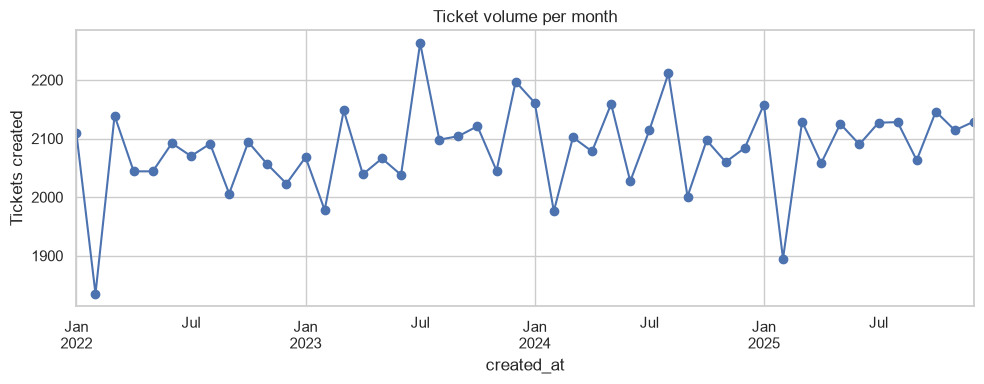

In [15]:
monthly = df.dropna(subset=['created_at']).set_index('created_at').resample('MS').size()

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, marker='o')
ax.set_ylabel('Tickets created')
ax.set_title('Ticket volume per month')
plt.tight_layout()
plt.show()

## 5. Resolution coverage

**Question:** what fraction of tickets have a recorded resolution at all? This is the single most important number for IncidentLens's core value proposition — retrieving historical resolutions only works for the tickets that have one.

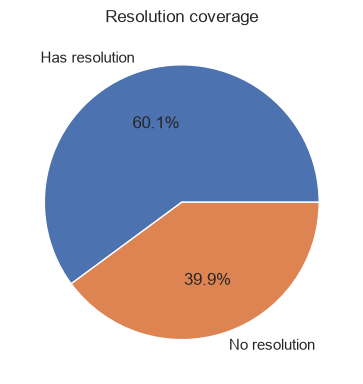

60.1% of tickets have a recorded resolution_summary


In [16]:
resolved_pct = df['has_resolution'].mean() * 100

fig, ax = plt.subplots(figsize=(4, 4))
df['has_resolution'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%',
                                          labels=['Has resolution', 'No resolution'])
ax.set_ylabel('')
ax.set_title('Resolution coverage')
plt.tight_layout()
plt.show()

print(f'{resolved_pct:.1f}% of tickets have a recorded resolution_summary')

## 6. Resolution time distribution

**Question:** among tickets that *were* resolved, how long does it typically take, and does it vary by priority? (Answers 'does high priority actually get resolved faster?')

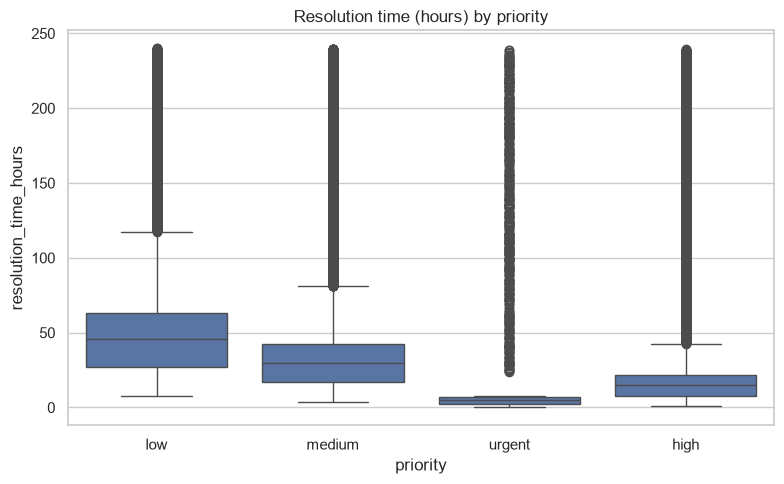

priority
urgent     4.910
high      14.745
medium    29.800
low       45.470
Name: resolution_time_hours, dtype: float64

In [17]:
resolved = df[df['has_resolution']]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=resolved, x='priority', y='resolution_time_hours', ax=ax)
ax.set_title('Resolution time (hours) by priority')
plt.tight_layout()
plt.show()

resolved.groupby('priority')['resolution_time_hours'].median().sort_values()

## 7. Incident description length

**Question:** how long are incident descriptions, and does length vary by priority or category? Relevant for Stage 6/7 — very short descriptions carry less signal for TF-IDF.

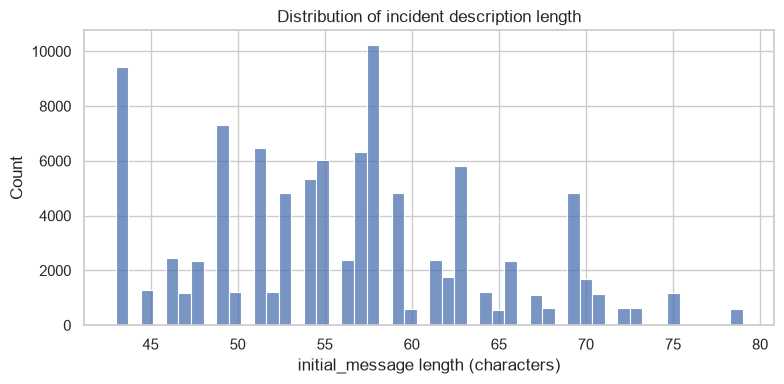

count    100000.0
mean     56.07974
std      8.040028
min          43.0
25%          50.0
50%          56.0
75%          61.0
max          79.0
Name: message_length, dtype: Float64

In [18]:
df['message_length'] = df['initial_message'].str.len()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['message_length'], bins=50, ax=ax)
ax.set_xlabel('initial_message length (characters)')
ax.set_title('Distribution of incident description length')
plt.tight_layout()
plt.show()

df['message_length'].describe()

## 8. Customer sentiment vs. resolution

**Question:** is there a relationship between customer sentiment and whether a ticket ends up with a recorded resolution? A pattern here would be a genuinely interesting, non-obvious finding worth including in the certification report.

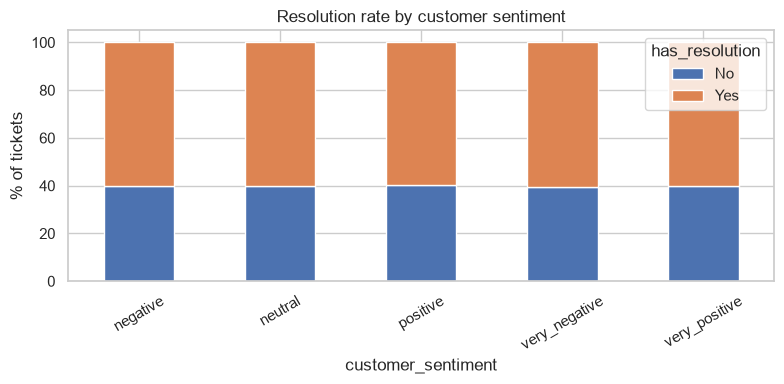

has_resolution,False,True
customer_sentiment,,
negative,40.1,59.9
neutral,39.7,60.3
positive,40.5,59.5
very_negative,39.5,60.5
very_positive,39.8,60.2


In [19]:
sentiment_resolution = pd.crosstab(df['customer_sentiment'], df['has_resolution'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 4))
sentiment_resolution.plot(kind='bar', stacked=True, ax=ax)
ax.set_ylabel('% of tickets')
ax.set_title('Resolution rate by customer sentiment')
ax.legend(title='has_resolution', labels=['No', 'Yes'])
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

sentiment_resolution.round(1)

## 9. Region distribution (post-cleaning)

**Question:** after filling missing `region` with `"unknown"` in Stage 4, how large is that `"unknown"` slice relative to real regions? This matters for whether region-based analysis in later stages is trustworthy.

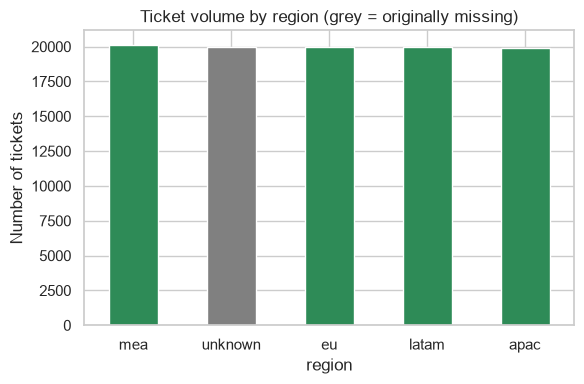

region
mea        20151
unknown    19997
eu         19960
latam      19959
apac       19933
Name: count, dtype: int64[pyarrow]

In [20]:
region_counts = df['region'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
region_counts.plot(kind='bar', ax=ax, color=['grey' if r == 'unknown' else 'seagreen' for r in region_counts.index])
ax.set_ylabel('Number of tickets')
ax.set_title('Ticket volume by region (grey = originally missing)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

region_counts

## Summary of findings

_Fill this in after actually running the notebook — do not write conclusions before seeing the real output. Suggested structure:_

- Most common issue types / whether `issue_type` is balanced enough for Stage 15 classification
- Whether ticket volume is stable, trending, or seasonal
- What % of tickets have no recorded resolution, and what that means for retrieval coverage
- Whether priority correlates with faster resolution
- Any sentiment/resolution or region pattern worth flagging